# Notebook18 – Executive Clone Screening Dashboard

---

## Goal of Notebook18

Previous notebooks built a comprehensive digital representation of CHO clone biology.

The project now contains information about:

- productivity
- quality
- stability
- process burden
- multi-omics programs
- dynamic cellular trajectories
- reinforcement-learning controllability
- controller robustness

However, these metrics are distributed across multiple notebooks.

The purpose of Notebook18 is to consolidate all available evidence into a single decision-making framework.

---

## Why This Matters

Cell Line Development (CLD) requires selecting a small number of candidates from a large clone population.

Poor decisions lead to:

- increased development cost
- delayed timelines
- manufacturing risk
- late-stage process failures

Notebook18 creates an integrated clone screening system that supports:

- clone advancement
- clone engineering
- clone termination

using all information generated throughout the project.

---

## Key Questions

For each clone:

- How productive is it?
- How stable is it?
- How robust is it?
- How controllable is it?
- How strong are its omics signatures?
- Should it move forward?

---

## Expected Outputs

Notebook18 generates:

- clone readiness scores
- candidate funnel classifications
- executive ranking tables
- top candidate dashboards

The final output represents a virtual CLD decision board.

## Section 1 – Load integrated datasets

Notebook18 combines outputs from previous notebooks.

Each dataset contributes a different perspective on clone performance.

Together they provide a comprehensive view of manufacturability and development readiness.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]

pareto = pd.read_csv(
    ROOT /
    "data/synthetic/pareto/" /
    "notebook10_final_pareto_recommendations_5000_legacy.csv"
)

burden = pd.read_csv(
    ROOT /
    "data/synthetic/process/" /
    "notebook12_process_burden_simulation_5000_legacy.csv"
)

omics = pd.read_csv(
    ROOT /
    "data/synthetic/omics/" /
    "notebook13_multiomics_latent_state_5000_legacy.csv"
)

robustness = pd.read_csv(
    ROOT /
    "data/synthetic/digital_twin/" /
    "notebook17_robustness_scorecard_5000_legacy.csv"
)

print("Pareto:", pareto.shape)
print("Burden:", burden.shape)
print("Omics:", omics.shape)
print("Robustness:", robustness.shape)

Pareto: (92, 18)
Burden: (92, 66)
Omics: (92, 93)
Robustness: (3, 4)


## Section 2 – Construct clone master table

The various evidence streams are merged into a single clone-level dataset.

This master table becomes the foundation for all downstream scoring and ranking.

In [2]:
master = burden.copy()

omics_cols_to_add = [
    "clone_id",
    "tx_secretion_program",
    "tx_stress_program",
    "tx_energy_metabolism",
    "tx_growth_program",
    "prot_secretory_capacity",
    "prot_folding_capacity",
    "prot_mito_activity",
    "prot_proteostasis_balance",
    "met_glycolytic_shift",
    "met_oxidative_state",
    "met_nutrient_pressure",
    "met_overflow_burden",
    "omics_latent_1",
    "omics_latent_2",
    "omics_latent_3",
    "omics_latent_4",
    "cellular_state",
    "cellular_archetype",
]

master = master.merge(
    omics[omics_cols_to_add],
    on="clone_id",
    how="left"
)

print("Master shape:", master.shape)
display(master.head())

Master shape: (94, 84)


,clone_id,process_condition,pareto_rank,candidate_archetype,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,...,met_glycolytic_shift,met_oxidative_state,met_nutrient_pressure,met_overflow_burden,omics_latent_1,omics_latent_2,omics_latent_3,omics_latent_4,cellular_state,cellular_archetype
0,CLONE_4625,stress_minimized,1.0,Rescue-value,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,...,0.567585,0.331344,0.518487,0.555266,4.402637,-0.910681,-0.404721,3.186541,0,Quality-Adapted
1,CLONE_4878,stress_minimized,2.0,Balanced,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,...,0.445703,0.064376,0.393058,0.366546,2.675861,-2.601021,1.133786,1.362528,0,Quality-Adapted
2,CLONE_3895,mild_temp_shift,3.0,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,...,0.056474,0.404215,0.144979,0.099176,-4.845263,0.200871,0.349792,0.838802,3,Balanced-Resilient
3,CLONE_3895,mild_temp_shift,3.0,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,...,0.028136,0.504324,0.145543,0.128355,-4.768517,0.790040,-1.619075,1.681215,3,Balanced-Resilient
4,CLONE_3895,balanced_feed,4.0,Quality-led,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,...,0.056474,0.404215,0.144979,0.099176,-4.845263,0.200871,0.349792,0.838802,3,Balanced-Resilient


## Section 3 – Productivity scoring

Productivity remains one of the most important economic drivers in biomanufacturing.

Clones with stronger productivity signals receive higher scores.

In [3]:
master["score_productivity"] = (
    100 *
    (
        master["productivity_signal"]
        -
        master["productivity_signal"].min()
    )
    /
    (
        master["productivity_signal"].max()
        -
        master["productivity_signal"].min()
    )
)

## Section 4 – Quality scoring

Product quality is evaluated using quality-related attributes generated during earlier analyses.

Higher quality scores indicate more desirable product characteristics.

In [4]:
master["score_quality"] = (
    master["obj_quality"] * 100
)

## Section 5 – Stability scoring

Stable clones reduce manufacturing risk and improve process reliability.

Clones with stronger stability metrics receive higher scores.

In [5]:
master["score_stability"] = (
    master["obj_stability"] * 100
)

## Section 6 – Burden penalty

High burden can negatively affect productivity, quality, and long-term process performance.

This section converts burden into a penalty term.

In [6]:
master["burden_penalty"] = (
    master["integrated_process_burden"] * 100
)

## Section 7 – Multi-omics score

Multi-omics measurements provide biological confidence beyond simple productivity metrics.

Strong secretory, metabolic, and translational programs contribute positively to clone readiness.

In [7]:
omics_cols = [
    "tx_secretion_program",
    "tx_energy_metabolism",
    "prot_secretory_capacity",
    "prot_folding_capacity",
    "met_oxidative_state",
]

master["omics_score"] = (
    master[omics_cols]
    .mean(axis=1)
    * 100
)

display(
    master[
        [
            "clone_id",
            "omics_score",
            *omics_cols
        ]
    ].head()
)

,clone_id,omics_score,tx_secretion_program,tx_energy_metabolism,prot_secretory_capacity,prot_folding_capacity,met_oxidative_state
0,CLONE_4625,17.302240,0.116551,0.155283,-0.082924,0.344858,0.331344
1,CLONE_4878,11.833808,-0.014176,0.305322,-0.073348,0.309516,0.064376
2,CLONE_3895,26.736152,0.263368,0.381080,0.105808,0.182337,0.404215
3,CLONE_3895,28.517580,0.286548,0.271697,0.223549,0.139761,0.504324
4,CLONE_3895,26.736152,0.263368,0.381080,0.105808,0.182337,0.404215


## Section 8 – RL robustness score

Notebook17 evaluated controller robustness under multiple stress scenarios.

This score represents how resilient and controllable a clone is expected to be during future process optimization.

In [8]:
# Section 8 – RL robustness score

# Notebook17 robustness is controller-level, not clone-level.
# Therefore, here we estimate clone-level RL readiness using available
# clone/process-level numeric controllability proxies.

candidate_rl_cols = [
    "rescue_potential_score",
    "burden_aware_rescue_score",
    "process_robustness",
    "rescue_potential",
]

available_rl_cols = [
    c for c in candidate_rl_cols
    if c in master.columns
]

print("Available RL proxy columns:", available_rl_cols)

# Convert available proxy columns to numeric.
# Text labels such as "Robust" or "Stable" become NaN and are ignored.
rl_numeric = (
    master[available_rl_cols]
    .apply(pd.to_numeric, errors="coerce")
)

# If no numeric proxy is available, fall back to neutral score.
if rl_numeric.shape[1] == 0 or rl_numeric.notna().sum().sum() == 0:
    master["rl_robustness_score"] = 50.0
else:
    master["rl_robustness_score"] = (
        rl_numeric
        .mean(axis=1)
        .fillna(0.5)
        * 100
    )

display(
    master[
        [
            "clone_id",
            "rl_robustness_score",
            *available_rl_cols
        ]
    ].head()
)

Available RL proxy columns: ['burden_aware_rescue_score', 'process_robustness']


,clone_id,rl_robustness_score,burden_aware_rescue_score,process_robustness
0,CLONE_4625,58.422895,0.584229,Stable
1,CLONE_4878,63.761372,0.637614,Stable
2,CLONE_3895,78.902602,0.789026,Robust
3,CLONE_3895,78.902602,0.789026,Robust
4,CLONE_3895,79.479074,0.794791,Robust


## Section 9 – Composite readiness score

All evidence streams are combined into a single readiness score.

The objective is to balance:

- productivity
- quality
- stability
- biological fitness
- controllability

while penalizing excessive burden.

In [9]:
master["overall_score"] = (
      0.30 * master["score_productivity"]
    + 0.20 * master["score_quality"]
    + 0.15 * master["score_stability"]
    + 0.15 * master["omics_score"]
    + 0.10 * master["rl_robustness_score"]
    - 0.10 * master["burden_penalty"]
)

,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,burden_penalty
count,94.000,94.000,94.000,94.000,94.000,94.000,94.000
mean,35.313,6.199,75.916,82.611,18.745,60.884,30.219
std,4.707,13.522,12.967,9.663,5.309,7.543,10.276
min,27.141,0.000,44.004,43.875,5.566,42.580,5.626
25%,32.740,1.170,67.959,81.460,15.328,55.977,21.961
50%,34.993,3.013,76.084,84.744,18.530,60.985,29.990
75%,37.232,5.887,85.766,88.153,22.080,65.351,37.809
max,59.324,100.000,98.964,100.000,30.257,79.479,55.435


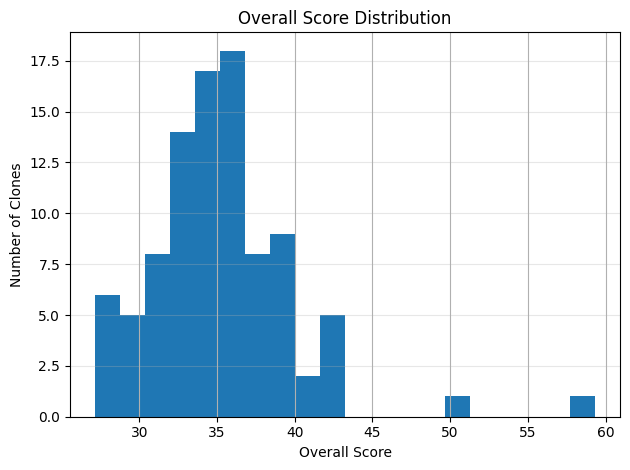

In [10]:
score_cols = [
    "overall_score",
    "score_productivity",
    "score_quality",
    "score_stability",
    "omics_score",
    "rl_robustness_score",
    "burden_penalty",
]

display(master[score_cols].describe().round(3))

master["overall_score"].hist(bins=20)

plt.title("Overall Score Distribution")
plt.xlabel("Overall Score")
plt.ylabel("Number of Clones")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Section 10 – Candidate funnel classification

Each clone is assigned a recommended action.

Categories include:

- Advance
- Advance with Monitoring
- Engineer
- Terminate

This mimics real-world CLD decision making.

In [11]:
advance_threshold = master["overall_score"].quantile(0.97)
monitor_threshold = master["overall_score"].quantile(0.88)
engineer_threshold = master["overall_score"].quantile(0.62)

print("Decision thresholds:")
print("Advance:", round(advance_threshold, 3))
print("Advance with Monitoring:", round(monitor_threshold, 3))
print("Engineer:", round(engineer_threshold, 3))

master["decision"] = np.select(
    [
        master["overall_score"] >= advance_threshold,
        master["overall_score"] >= monitor_threshold,
        master["overall_score"] >= engineer_threshold,
    ],
    [
        "Advance",
        "Advance with Monitoring",
        "Engineer",
    ],
    default="Terminate"
)

display(master["decision"].value_counts())

Decision thresholds:
Advance: 42.68
Advance with Monitoring: 39.406
Engineer: 36.016


decision
Terminate                  58
Engineer                   24
Advance with Monitoring     9
Advance                     3
Name: count, dtype: int64

## Section 11 – Executive ranking

Clones are ranked according to their overall readiness score.

Higher-ranked clones become stronger candidates for experimental validation.

In [12]:
ranking = (
    master
    .sort_values(
        "overall_score",
        ascending=False
    )
)

display(
    ranking[
        [
            "clone_id",
            "overall_score",
            "decision"
        ]
    ]
    .head(20)
)

,clone_id,overall_score,decision
0,CLONE_4625,59.323924,Advance
1,CLONE_4878,51.055084,Advance
5,CLONE_3895,42.862936,Advance
3,CLONE_3895,42.631425,Advance with Monitoring
4,CLONE_3895,42.595722,Advance with Monitoring
2,CLONE_3895,42.364211,Advance with Monitoring
24,CLONE_0080,42.126019,Advance with Monitoring
12,CLONE_1633,40.895251,Advance with Monitoring
10,CLONE_3249,40.267179,Advance with Monitoring
20,CLONE_3269,39.714494,Advance with Monitoring


## Section 12 – Recommendation Distribution

This section visualizes how many clones fall into each final recommendation category.

This is not a sequential funnel yet.

Instead, it shows the final decision distribution after applying the composite readiness score.

Categories include:

- Advance
- Advance with Monitoring
- Engineer
- Terminate

A realistic CLD screening output should usually contain a small number of strong candidates, a moderate number of engineering or monitoring candidates, and many rejected clones.

decision
Advance                     3
Advance with Monitoring     9
Engineer                   24
Terminate                  58
Name: count, dtype: int64

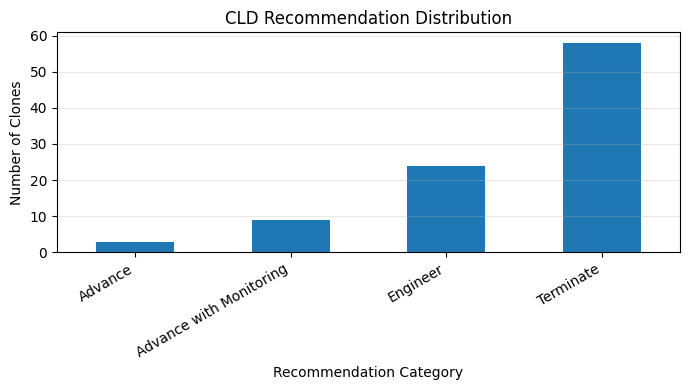

In [13]:
decision_order = [
    "Advance",
    "Advance with Monitoring",
    "Engineer",
    "Terminate",
]

decision_counts = (
    master["decision"]
    .value_counts()
    .reindex(decision_order, fill_value=0)
)

display(decision_counts)

decision_counts.plot.bar(figsize=(7, 4))

plt.title("CLD Recommendation Distribution")
plt.xlabel("Recommendation Category")
plt.ylabel("Number of Clones")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Section 12b – CLD Funnel View

This section converts the final recommendation categories into a simplified executive funnel.

The funnel shows how the original candidate pool narrows into higher-priority groups.

This view is useful for portfolio review and management-level communication.

,stage,count
0,All screened clones,94
1,Non-terminated clones,36
2,Engineer or better,36
3,Monitoring or better,12
4,Advance,3


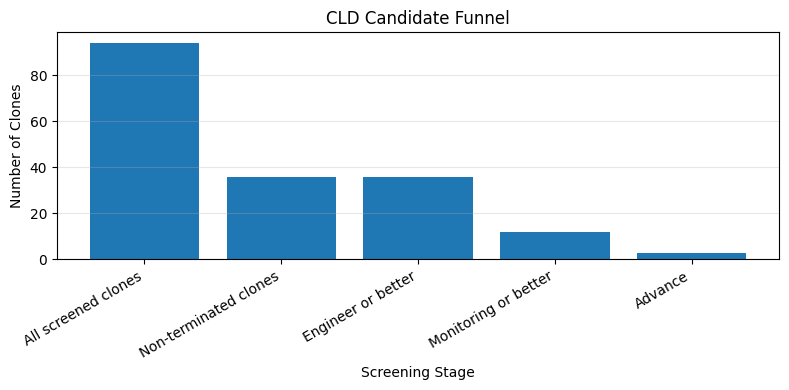

In [14]:
funnel_counts = pd.DataFrame({
    "stage": [
        "All screened clones",
        "Non-terminated clones",
        "Engineer or better",
        "Monitoring or better",
        "Advance",
    ],
    "count": [
        len(master),
        (master["decision"] != "Terminate").sum(),
        master["decision"].isin(
            ["Engineer", "Advance with Monitoring", "Advance"]
        ).sum(),
        master["decision"].isin(
            ["Advance with Monitoring", "Advance"]
        ).sum(),
        (master["decision"] == "Advance").sum(),
    ]
})

display(funnel_counts)

plt.figure(figsize=(8, 4))
plt.bar(
    funnel_counts["stage"],
    funnel_counts["count"]
)

plt.title("CLD Candidate Funnel")
plt.xlabel("Screening Stage")
plt.ylabel("Number of Clones")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Section 13 – Top candidate dashboard

Detailed metrics for top-ranked clones are displayed.

This dashboard supports final review before experimental advancement.

In [15]:
dashboard = ranking[
    [
        "clone_id",
        "overall_score",
        "score_productivity",
        "score_quality",
        "score_stability",
        "omics_score",
        "rl_robustness_score",
        "decision"
    ]
]

display(dashboard.head(25))

,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision
0,CLONE_4625,59.323924,100.000000,69.850174,83.065313,17.302240,58.422895,Advance
1,CLONE_4878,51.055084,79.679015,66.381308,69.204240,11.833808,63.761372,Advance
5,CLONE_3895,42.862936,1.170372,98.964170,82.267468,28.517580,79.479074,Advance
3,CLONE_3895,42.631425,1.170372,98.607662,82.267468,28.517580,78.902602,Advance with Monitoring
4,CLONE_3895,42.595722,1.170372,98.964170,82.267468,26.736152,79.479074,Advance with Monitoring
2,CLONE_3895,42.364211,1.170372,98.607662,82.267468,26.736152,78.902602,Advance with Monitoring
24,CLONE_0080,42.126019,0.296049,89.439926,88.808949,27.907134,72.044430,Advance with Monitoring
12,CLONE_1633,40.895251,0.393682,93.343811,84.791981,30.257371,64.680960,Advance with Monitoring
10,CLONE_3249,40.267179,3.014994,89.331572,88.180818,23.483599,67.737773,Advance with Monitoring
20,CLONE_3269,39.714494,3.635014,88.244089,87.794295,26.774143,66.741534,Advance with Monitoring


## Section 14 – Export decision datasets

Final clone rankings and dashboard outputs are exported for future notebooks and reporting.

In [16]:
OUT = (
    ROOT /
    "data/synthetic/digital_twin"
)

dashboard.to_csv(
    OUT /
    "notebook18_candidate_dashboard_5000_legacy.csv",
    index=False
)

ranking.to_csv(
    OUT /
    "notebook18_clone_ranking_5000_legacy.csv",
    index=False
)

print("Notebook18 export complete.")

Notebook18 export complete.


# Notebook18 Summary

Notebook18 integrated outputs from across the project into a unified clone screening framework.

Major achievements:

- consolidated biological evidence
- integrated multi-omics information
- incorporated RL robustness
- generated readiness scores
- classified clone recommendations
- ranked clone candidates

This notebook represents the first complete virtual CLD review board within the project.

The resulting dashboard provides actionable recommendations for clone advancement, engineering, or termination.

Notebook18 reconnects the digital twin and reinforcement-learning framework back to the original goal of accelerated clone selection.

# References

1. Wurm FM.
   Production of Recombinant Protein Therapeutics in Cultivated Mammalian Cells.
   Nature Biotechnology (2004).
   DOI: 10.1038/nbt1026

2. Kim JY, Kim YG, Lee GM.
   CHO Cells in Biotechnology for Production of Recombinant Proteins.
   Current Opinion in Biotechnology (2012).
   DOI: 10.1016/j.copbio.2011.10.002

3. Rathore AS, Winkle H.
   Quality by Design for Biopharmaceuticals.
   Nature Biotechnology (2009).
   DOI: 10.1038/nbt0909-26

4. Sutton RS, Barto AG.
   Reinforcement Learning: An Introduction (2nd Edition).
   MIT Press, 2018.

5. Tao F, Zhang H, Liu A, Nee AYC.
   Digital Twin in Industry: State-of-the-Art.
   IEEE Transactions on Industrial Informatics.
   DOI: 10.1109/TII.2018.2873186

6. Hasin Y, Seldin M, Lusis A.
   Multi-omics Approaches to Disease.
   Genome Biology (2017).
   DOI: 10.1186/s13059-017-1215-1